In [1]:
!pip install tensorflow matplotlib opencv-python scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)


C:\Users\singh\jupyter-311\Scripts\python.exe


In [3]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\singh\jupyter-311\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\singh\jupyter-311\Scripts\python.exe -m pip install --upgrade pip


In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as bnp
import os

# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [6]:
train_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\train"

val_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\val"

test_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\test"

In [7]:
print(os.listdir(train_path))

['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 7267 images belonging to 15 classes.


In [11]:
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1550 images belonging to 15 classes.


In [12]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1556 images belonging to 15 classes.


In [13]:
print(train_generator.class_indices)

{'beige': 0, 'black': 1, 'blue': 2, 'brown': 3, 'gold': 4, 'green': 5, 'grey': 6, 'orange': 7, 'pink': 8, 'purple': 9, 'red': 10, 'silver': 11, 'tan': 12, 'white': 13, 'yellow': 14}


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [15]:
# Freez base layer

for layer in base_model.layers:
    layer.trainable = False
    

In [16]:
# Add classifiacation layers

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model = Model(
    inputs = base_model.input,
    outputs = predictions
)

In [17]:
# Compile Model
model.compile(
    optimizer = 'adam',
    loss ='categorical_crossentropy',
    metrics = ['accuracy']
)


In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accuracy: 0.4776 - loss: 1.5857 - val_accuracy: 0.6065 - val_loss: 1.2006
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.6575 - loss: 0.9944 - val_accuracy: 0.6755 - val_loss: 1.0007
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.7185 - loss: 0.8178 - val_accuracy: 0.6619 - val_loss: 0.9880
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.7644 - loss: 0.7007 - val_accuracy: 0.6865 - val_loss: 0.8936
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7896 - loss: 0.6192 - val_accuracy: 0.6884 - val_loss: 0.8976


In [19]:
model.save("car_color_model.h5")

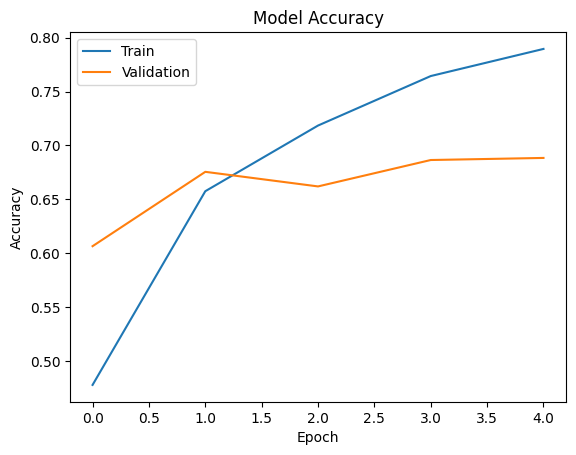

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

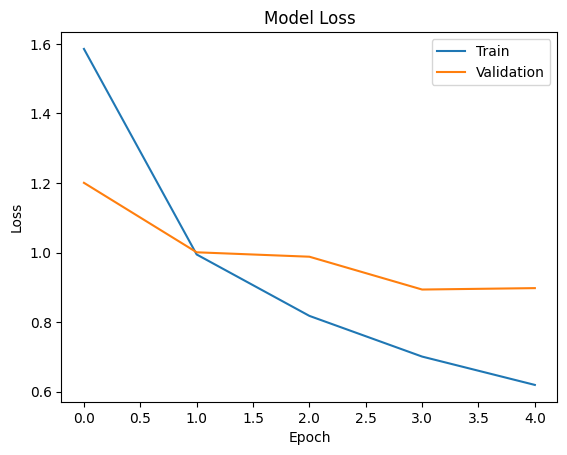

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 853ms/step - accuracy: 0.6562 - loss: 1.0195
Test Accuracy: 0.6561696529388428


In [23]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
!pip install ultralytics


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import sys
!{sys.executable} -m pip install ultralytics


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\singh\jupyter-311\Scripts\python.exe -m pip install --upgrade pip


In [27]:
from ultralytics import YOLO
import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [28]:
# Loading YOLO Model
yolo_model = YOLO("yolov8n.pt")

In [29]:
# Load Your Trained Color Model
color_model = load_model("car_color_model.h5")

In [30]:
# Define Class Labels

class_labels = [
    'beige',
    'black',
    'blue',
    'brown',
    'gold',
    'green',
    'grey',
    'orange',
    'pink',
    'purple',
    'red',
    'silver',
    'tan',
    'white',
    'yellow'
]

In [31]:
print(train_generator.class_indices)

{'beige': 0, 'black': 1, 'blue': 2, 'brown': 3, 'gold': 4, 'green': 5, 'grey': 6, 'orange': 7, 'pink': 8, 'purple': 9, 'red': 10, 'silver': 11, 'tan': 12, 'white': 13, 'yellow': 14}


In [32]:
# # Upload Traffic Image

# from google.colab import files

# uploaded = files.upload()

In [33]:
# C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8\valid\labels

train_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\train"

val_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\val"

test_path = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\test"

In [34]:
import os

dataset_path = r"C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8"  # change this

print(os.listdir(dataset_path))

['data.yaml', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [35]:
import os

train_path = r"C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8\train"

print(os.listdir(train_path))

['images', 'labels']


In [36]:
import os
import cv2

images_folder = r"C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8\train\images"

image_file = os.listdir(images_folder)[0]

image_path = os.path.join(images_folder, image_file)

print(image_path)

image = cv2.imread(image_path)

print(image.shape)

C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8\train\images\000002_jpeg.rf.217c7dfeb2b51149491eadb807130750.jpg
(640, 640, 3)


In [37]:
results = yolo_model(image)


0: 640x640 3 cars, 402.7ms
Speed: 23.7ms preprocess, 402.7ms inference, 26.2ms postprocess per image at shape (1, 3, 640, 640)


In [38]:
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        print(yolo_model.names[cls_id])

car
car
car


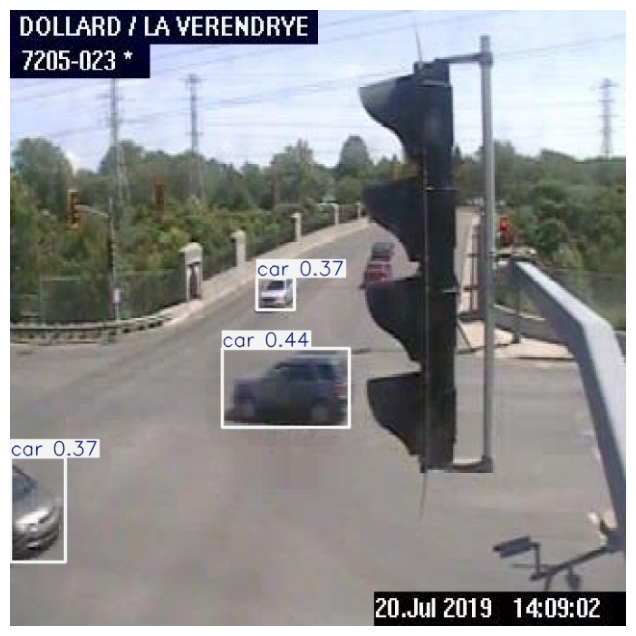

In [39]:
# Visualizing Detection

import matplotlib.pyplot as plt
import cv2

result_img = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [40]:
print(train_generator.class_indices)

{'beige': 0, 'black': 1, 'blue': 2, 'brown': 3, 'gold': 4, 'green': 5, 'grey': 6, 'orange': 7, 'pink': 8, 'purple': 9, 'red': 10, 'silver': 11, 'tan': 12, 'white': 13, 'yellow': 14}


In [41]:
import cv2
import numpy as np

output_image = image.copy()

car_count = 0
people_count = 0

for r in results:

    for box in r.boxes:

        cls_id = int(box.cls[0])
        cls_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # PERSON COUNT
        if cls_name == "person":

            people_count += 1

            cv2.rectangle(
                output_image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

        # CAR DETECTION
        elif cls_name == "car":

            car_count += 1

            car_crop = image[y1:y2, x1:x2]

            if car_crop.size == 0:
                continue
                
            car_crop = cv2.cvtColor(car_crop, cv2.COLOR_BGR2RGB)

            # Resize for classifier
            resized = cv2.resize(car_crop, (224, 224))

            resized = resized.astype("float32") / 255.0

            resized = np.expand_dims(resized, axis=0)

            # Predict color
            prediction = color_model.predict(resized, verbose=0)

            predicted_class = np.argmax(prediction)

            color_name = class_labels[predicted_class]

            # Internship requirement
            if color_name.lower() == "blue":

                rectangle_color = (0, 0, 255)   # RED

            else:

                rectangle_color = (255, 0, 0)   # BLUE

            cv2.rectangle(
                output_image,
                (x1, y1),
                (x2, y2),
                rectangle_color,
                3
            )

            cv2.putText(
                output_image,
                color_name,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                rectangle_color,
                2
            )

print("Cars:", car_count)
print("People:", people_count)

Cars: 3
People: 0


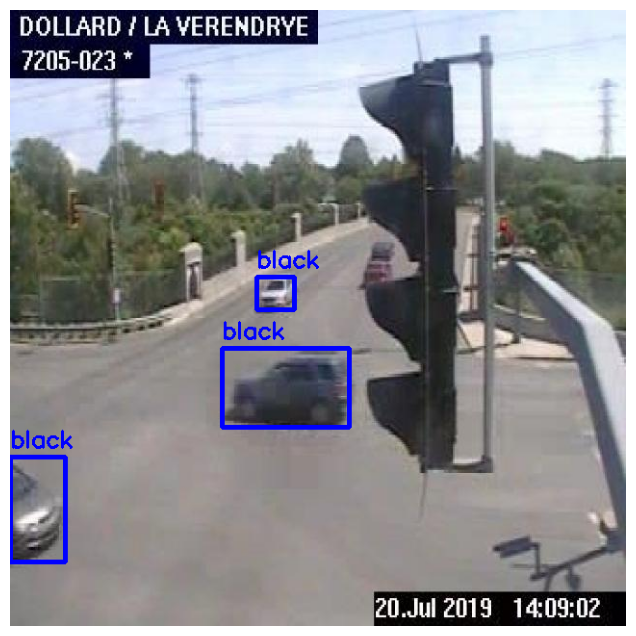

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

In [43]:
print("Predicted Color:", color_name)
print("Confidence:", np.max(prediction))
print("----------------")

Predicted Color: black
Confidence: 0.67132246
----------------


In [44]:
img = cv2.imread(r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\train\blue\f9cc09b0ff.jpg")
img = cv2.imread(r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\train\blue\f93e48bbfb.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = color_model.predict(img, verbose=0)

predicted_class = np.argmax(prediction)

print("Predicted Color:", class_labels[predicted_class])
print("Confidence:", np.max(prediction))

Predicted Color: blue
Confidence: 0.9998572


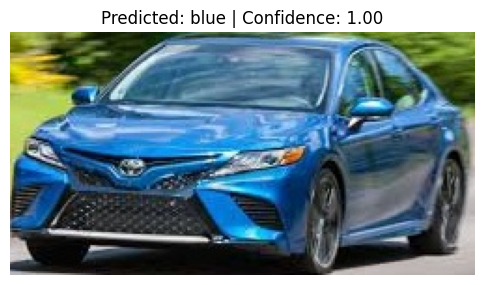

Predicted Color: blue
Confidence: 0.9998572


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(
    r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\train\blue\f93e48bbfb.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Keep a copy for display
display_img = img_rgb.copy()

# Prepare image for prediction
img_resized = cv2.resize(img_rgb, (224, 224))
img_resized = img_resized.astype("float32") / 255.0
img_resized = np.expand_dims(img_resized, axis=0)

# Predict
prediction = color_model.predict(img_resized, verbose=0)

predicted_class = np.argmax(prediction)
predicted_color = class_labels[predicted_class]
confidence = np.max(prediction)

# Display image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(display_img)
plt.title(f"Predicted: {predicted_color} | Confidence: {confidence:.2f}")
plt.axis("off")
plt.show()

# Print results
print("Predicted Color:", predicted_color)
print("Confidence:", confidence)

In [46]:
# print(color_model.input_shape)

In [47]:
prediction = color_model.predict(img_resized, verbose=0)[0]

top5 = np.argsort(prediction)[-5:][::-1]

print("Top 5 Predictions:")
for idx in top5:
    print(f"{class_labels[idx]} : {prediction[idx]:.4f}")

Top 5 Predictions:
blue : 0.9999
green : 0.0001
black : 0.0000
brown : 0.0000
purple : 0.0000


In [48]:
import os
import random

blue_folder = r"C:\Users\singh\Downloads\car_detection_project\VCoR (Vehicle Color Recognition) Dataset\test\blue"

files = random.sample(os.listdir(blue_folder), 10)

correct = 0

for file in files:

    path = os.path.join(blue_folder, file)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (224,224))
    img_resized = img_resized.astype("float32") / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    prediction = color_model.predict(img_resized, verbose=0)

    predicted_class = np.argmax(prediction)
    predicted_color = class_labels[predicted_class]

    print(file, "->", predicted_color)

    if predicted_color == "blue":
        correct += 1

print("Correct:", correct, "/ 10")

3b1667b2b8.jpg -> blue
246797ded3.jpg -> blue
3b5e964079.jpg -> blue
fc0797898c.jpg -> blue
3ecce0aebe.jpg -> blue
e774c95f50.jpg -> blue
01401b6d76.jpg -> blue
d3d8bd7289.jpg -> blue
837676f754.jpg -> blue
f66104ad0a.jpg -> blue
Correct: 10 / 10


In [65]:
# Loading one traffic image
import os
import cv2

images_folder = r"C:\Users\singh\Downloads\car_detection_project\Intersection Traffic Dataset.v1-v1.0.yolov8\train\images"


image_file = os.listdir(images_folder)[2]

image_path = os.path.join(images_folder, image_file)

image = cv2.imread(image_path)

print(image.shape)

(640, 640, 3)


In [69]:
# Optional
class_labels = [
    'beige', 'black', 'blue', 'brown', 'gold',
    'green', 'grey', 'orange', 'pink', 'purple',
    'red', 'silver', 'tan', 'white', 'yellow'
]

In [70]:
output_image = image.copy()

car_count = 0
people_count = 0

for r in results:

    for box in r.boxes:

        cls_id = int(box.cls[0])
        cls_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if cls_name == "car":

            car_count += 1

            car_crop = image[y1:y2, x1:x2]

            if car_crop.size == 0:
                continue

            car_crop = cv2.cvtColor(
                car_crop,
                cv2.COLOR_BGR2RGB
            )

            car_crop = cv2.resize(
                car_crop,
                (224,224)
            )

            car_crop = car_crop.astype(
                "float32"
            ) / 255.0

            car_crop = np.expand_dims(
                car_crop,
                axis=0
            )

            prediction = color_model.predict(
                car_crop,
                verbose=0
            )

            predicted_class = np.argmax(
                prediction
            )

            color_name = class_labels[
                predicted_class
            ]

            print(
                f"Car {car_count}: "
                f"{color_name} "
                f"({np.max(prediction):.2f})"
            )

            if color_name == "blue":

                rectangle_color = (
                    0,0,255
                )

            else:

                rectangle_color = (
                    255,0,0
                )

            cv2.rectangle(
                output_image,
                (x1,y1),
                (x2,y2),
                rectangle_color,
                3
            )

            cv2.putText(
                output_image,
                color_name,
                (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                rectangle_color,
                2
            )

Car 1: grey (0.66)
Car 2: black (0.42)


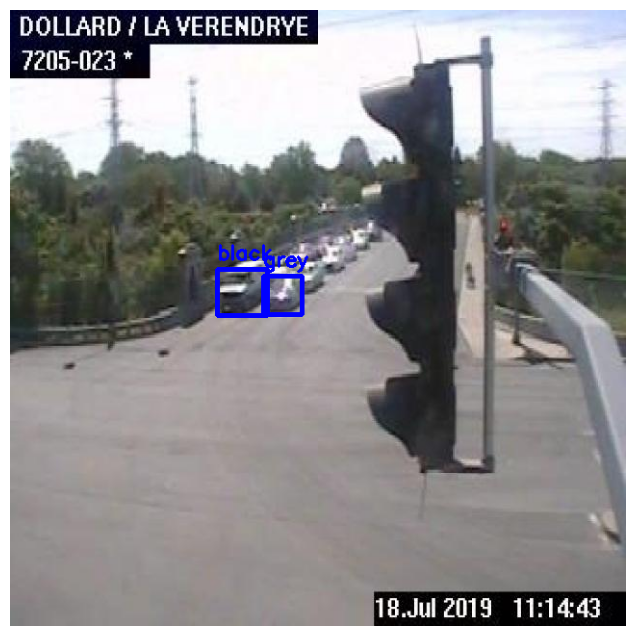

In [71]:
plt.figure(figsize=(12,8))

plt.imshow(
    cv2.cvtColor(
        output_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.show()

In [73]:
# Adding counts on the image
cv2.putText(
    output_image,
    f"Cars: {car_count}",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

cv2.putText(
    output_image,
    f"People: {people_count}",
    (20, 80),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

array([[[ 47,   9,   5],
        [ 42,   4,   0],
        [ 40,   2,   0],
        ...,
        [250, 207, 186],
        [250, 207, 186],
        [251, 208, 187]],

       [[ 45,   7,   3],
        [ 40,   2,   0],
        [ 39,   1,   0],
        ...,
        [250, 207, 186],
        [251, 208, 187],
        [251, 208, 187]],

       [[ 46,   5,   2],
        [ 41,   0,   0],
        [ 37,   0,   0],
        ...,
        [250, 207, 186],
        [251, 208, 187],
        [252, 209, 188]],

       ...,

       [[126, 127, 123],
        [126, 127, 123],
        [126, 127, 125],
        ...,
        [  3,   1,   1],
        [  3,   1,   1],
        [  3,   1,   1]],

       [[126, 127, 123],
        [126, 127, 123],
        [126, 127, 125],
        ...,
        [  3,   1,   1],
        [  3,   1,   1],
        [  3,   1,   1]],

       [[126, 127, 123],
        [126, 127, 123],
        [126, 127, 125],
        ...,
        [  3,   1,   1],
        [  3,   1,   1],
        [  3,   1,   1]]

In [75]:
cv2.imwrite("output_result.jpg", output_image)

True

# GUI



In [76]:
# Installation
import sys
!{sys.executable} -m pip install gradio

     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 43.1/43.1 kB ? eta 0:00:00
     ---------------------------------------- 0.0/109.4 kB ? eta -:--:--
     -------------- ------------------------- 41.0/109.4 kB ? eta -:--:--
     -------------------- ---------------- 61.4/109.4 kB 812.7 kB/s eta 0:00:01
     ------------------------------------ 109.4/109.4 kB 901.4 kB/s eta 0:00:00
     ---------------------------------------- 0.0/58.7 kB ? eta -:--:--
     ---------------------------------------- 58.7/58.7 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/32.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/32.3 MB 3.2 MB/s eta 0:00:11
   ---------------------------------------- 0.2/32.3 MB 2.3 MB/s eta 0:00:15
   ---------------------------------------- 0.4/32.3 MB 2.7 MB/s eta 0:00:12
    --------------------------------------- 0.5/32.3 MB 2.8 MB/s eta 0:00:12
    --------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\singh\jupyter-311\Scripts\python.exe -m pip install --upgrade pip


In [78]:
import gradio as gr

def process_image(input_image):

    results = yolo_model(input_image)

    output_image = results[0].plot()

    return output_image

gr.Interface(
    fn=process_image,
    inputs=gr.Image(),
    outputs=gr.Image(),
    title="Car Color Detection System"
).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.



0: 640x640 1 person, 9 cars, 305.9ms
Speed: 189.9ms preprocess, 305.9ms inference, 11.6ms postprocess per image at shape (1, 3, 640, 640)


In [82]:
import cv2
import numpy as np

class_labels = [
    'beige', 'black', 'blue', 'brown', 'gold',
    'green', 'grey', 'orange', 'pink', 'purple',
    'red', 'silver', 'tan', 'white', 'yellow'
]

def process_image(input_image):

    image = cv2.cvtColor(input_image, cv2.COLOR_RGB2BGR)

    results = yolo_model(image)

    output_image = image.copy()

    car_count = 0
    people_count = 0

    for r in results:

        for box in r.boxes:

            cls_id = int(box.cls[0])
            cls_name = yolo_model.names[cls_id]

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Person detection
            if cls_name == "person":

                people_count += 1

                cv2.rectangle(
                    output_image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

            # Car detection
            elif cls_name == "car":

                car_count += 1

                car_crop = image[y1:y2, x1:x2]

                if car_crop.size == 0:
                    continue

                car_crop = cv2.cvtColor(
                    car_crop,
                    cv2.COLOR_BGR2RGB
                )

                car_crop = cv2.resize(
                    car_crop,
                    (224, 224)
                )

                car_crop = car_crop.astype("float32") / 255.0

                car_crop = np.expand_dims(
                    car_crop,
                    axis=0
                )

                prediction = color_model.predict(
                    car_crop,
                    verbose=0
                )

                predicted_class = np.argmax(prediction)

                color_name = class_labels[predicted_class]

                # Internship requirement
                if color_name == "blue":

                    rectangle_color = (0, 0, 255)   # RED

                else:

                    rectangle_color = (255, 0, 0)   # BLUE

                cv2.rectangle(
                    output_image,
                    (x1, y1),
                    (x2, y2),
                    rectangle_color,
                    3
                )

                cv2.putText(
                    output_image,
                    color_name,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    rectangle_color,
                    2
                )

    cv2.putText(
        output_image,
        f"Cars: {car_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        output_image,
        f"People: {people_count}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    return cv2.cvtColor(
        output_image,
        cv2.COLOR_BGR2RGB
    )

In [85]:
import gradio as gr

gr.Interface(
    fn=process_image,
    inputs=gr.Image(),
    outputs=gr.Image(),
    title="Car Color Detection & Traffic Monitoring System"
).launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.



0: 640x640 10 persons, 3 cars, 1 truck, 1 traffic light, 140.5ms
Speed: 83.0ms preprocess, 140.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
